# Melbourne Housing — exploratory data analysis

Dataset: `data/melb_data.csv` (Kaggle Melbourne Housing). Goal: understand distributions, missingness, and relationships with `Price` before modelling.

In [6]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = Path("..") / "data" / "melb_data.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Shape, dtypes, and missing values

Expect ~13.5k rows. Several columns have substantial missing rates (notably `BuildingArea`, `YearBuilt`).

In [7]:
print("shape:", df.shape)
display(df.dtypes)
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(null_pct.round(2))

shape: (13580, 21)


Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

BuildingArea     47.50
YearBuilt        39.58
CouncilArea      10.08
Car               0.46
Suburb            0.00
Price             0.00
Type              0.00
Rooms             0.00
Address           0.00
Distance          0.00
Method            0.00
Date              0.00
SellerG           0.00
Bathroom          0.00
Bedroom2          0.00
Postcode          0.00
Landsize          0.00
Lattitude         0.00
Longtitude        0.00
Regionname        0.00
Propertycount     0.00
dtype: float64

In [8]:
df["Suburb"].nunique()

314

**Findings:** `BuildingArea` and `YearBuilt` often exceed ~20% missing — median imputation in the pipeline is appropriate. `Suburb` has high cardinality (~300); grouping rare suburbs into `"Other"` reduces noise for encoders. `Car` has a small amount of missing values.

## Target variable: `Price`

Sale prices are typically right-skewed; a log transform often improves regression metrics.

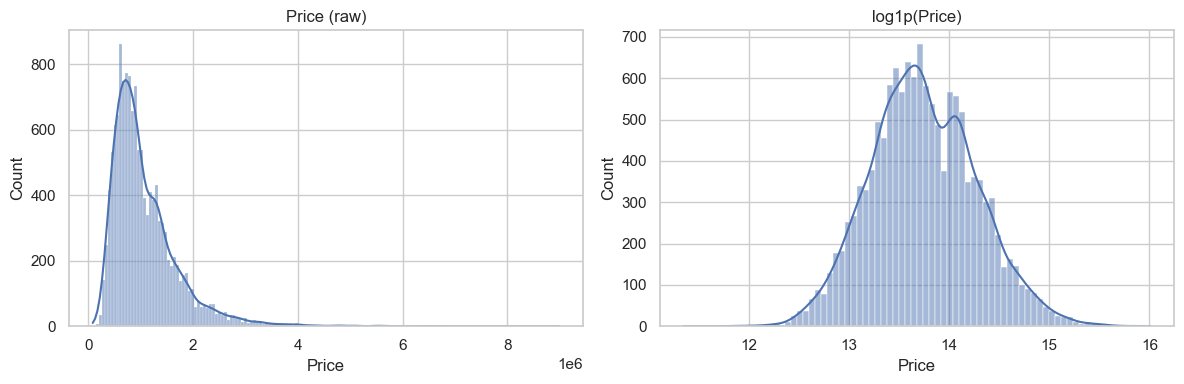

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Price"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Price (raw)")
sns.histplot(np.log1p(df["Price"].dropna()), kde=True, ax=axes[1])
axes[1].set_title("log1p(Price)")
plt.tight_layout()
plt.show()

## Numeric features — distributions (sample)

Key structural features: `Rooms`, `Distance`, `Landsize`, `BuildingArea`.

In [10]:
num_cols = ["Rooms", "Distance", "Bedroom2", "Bathroom", "Car", "Landsize", "BuildingArea", "YearBuilt"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997,0.955748,1.0,2.0,3.0,3.0,10.0
Distance,13580.0,10.137776,5.868725,0.0,6.1,9.2,13.0,48.1
Bedroom2,13580.0,2.914728,0.965921,0.0,2.0,3.0,3.0,20.0
Bathroom,13580.0,1.534242,0.691712,0.0,1.0,1.0,2.0,8.0
Car,13518.0,1.610075,0.962634,0.0,1.0,2.0,2.0,10.0
Landsize,13580.0,558.416127,3990.669241,0.0,177.0,440.0,651.0,433014.0
BuildingArea,7130.0,151.967650,541.014538,0.0,93.0,126.0,174.0,44515.0
YearBuilt,8205.0,1964.684217,37.273762,1196.0,1940.0,1970.0,1999.0,2018.0


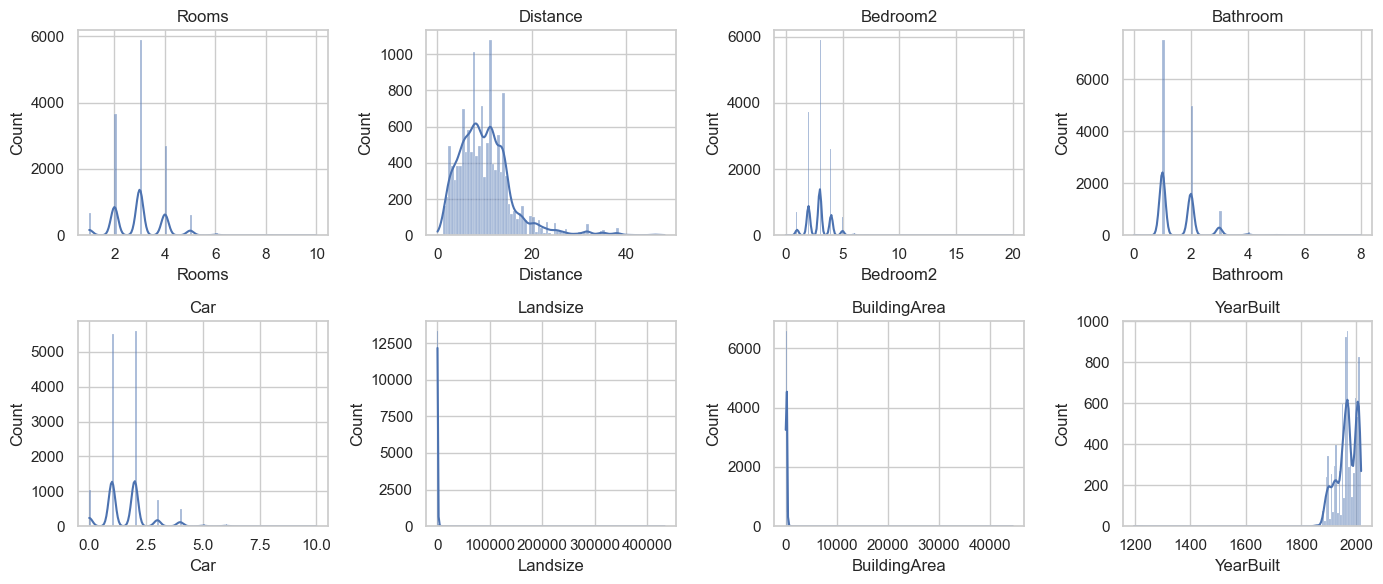

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

## Correlation among numeric features and `Price`

Helps identify strong linear predictors before tree-based modelling.

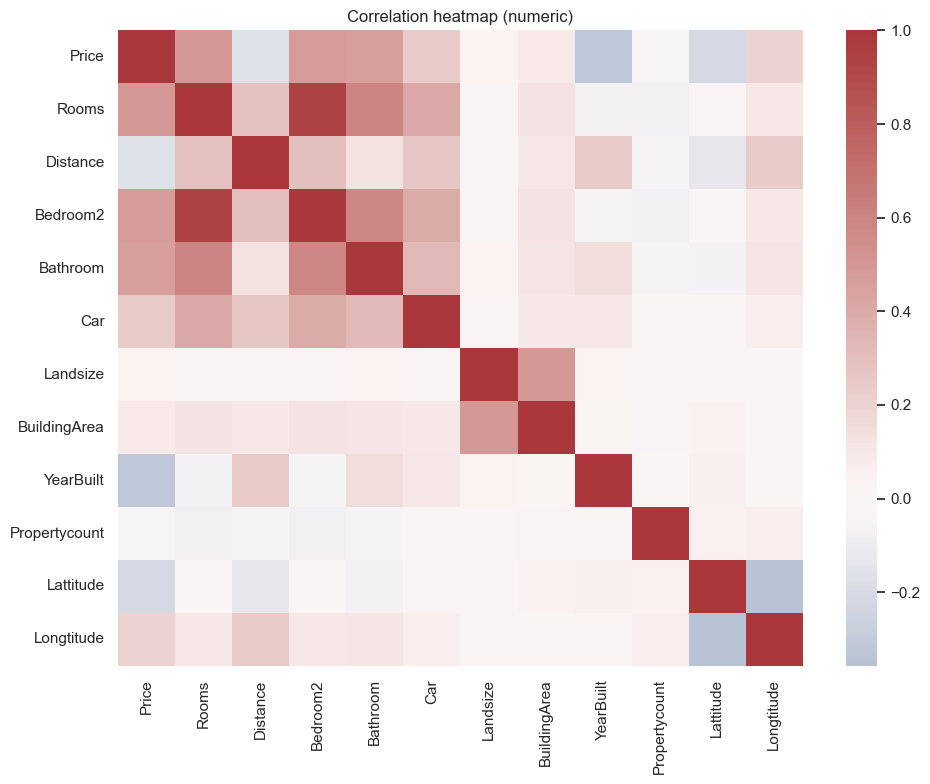

Price            1.000000
Rooms            0.496634
Bedroom2         0.475951
Bathroom         0.467038
Car              0.238979
Longtitude       0.203656
BuildingArea     0.090981
Landsize         0.037507
Propertycount   -0.042153
Distance        -0.162522
Lattitude       -0.212934
YearBuilt       -0.323617
Name: Price, dtype: float64

In [12]:
corr_cols = ["Price", "Rooms", "Distance", "Bedroom2", "Bathroom", "Car", "Landsize", "BuildingArea", "YearBuilt", "Propertycount", "Lattitude", "Longtitude"]
cm = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="vlag", center=0)
plt.title("Correlation heatmap (numeric)")
plt.tight_layout()
plt.show()
cm["Price"].sort_values(ascending=False)

## Summary

- **Rows/columns:** ~13.5k listings; mix of categorical and numeric predictors.
- **Missing data:** Plan median imputation for numeric gaps; consider `Car` as numeric with imputation.
- **Target:** `Price` is right-skewed — training can use `log1p` on `Price` with inverse transform on predictions.
- **Suburb:** Many levels — rare-category grouping before one-hot or similar encoding.
- **Next:** `src/preprocess.py` + `src/train.py` implement the pipeline; Streamlit reuses the same feature set.